<a href="https://colab.research.google.com/github/mtalhak003/AI-ML-Deep-Learning/blob/main/Comparison%20of%20Random%20Forest%2CAdaBoost%2C%20and%20Gradient%20Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install kagglehub pandas numpy scikit-learn matplotlib seaborn

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("devansodariya/student-performance-data")

print("Path to dataset files:", path)

100%|██████████| 7.16k/7.16k [00:00<00:00, 4.44MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/devansodariya/student-performance-data/versions/1


In [3]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Show files inside downloaded folder
print(os.listdir(path))

['student_data.csv']


In [6]:
file_path = os.path.join(path, "student_data.csv")

df = pd.read_csv(file_path)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
df['pass_fail'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [9]:
df = df.drop(['G1','G2','G3'], axis=1)

In [10]:
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

In [11]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,pass_fail
0,0,0,18,1,0,0,4,4,0,4,...,0,0,4,3,4,1,1,3,6,0
1,0,0,17,1,0,1,1,1,0,2,...,1,0,5,3,3,1,1,3,4,0
2,0,0,15,1,1,1,1,1,0,2,...,1,0,4,3,2,2,3,3,10,1
3,0,0,15,1,0,1,4,2,1,3,...,1,1,3,2,2,1,1,5,2,1
4,0,0,16,1,0,1,3,3,2,2,...,0,0,4,3,2,1,2,5,4,1


In [12]:
X = df.drop("pass_fail", axis=1)
y = df["pass_fail"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7215189873417721


In [15]:
print(confusion_matrix(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))

[[ 8 19]
 [ 3 49]]
              precision    recall  f1-score   support

           0       0.73      0.30      0.42        27
           1       0.72      0.94      0.82        52

    accuracy                           0.72        79
   macro avg       0.72      0.62      0.62        79
weighted avg       0.72      0.72      0.68        79



In [16]:
ada_model = AdaBoostClassifier(n_estimators=200, random_state=42)

ada_model.fit(X_train, y_train)

ada_predictions = ada_model.predict(X_test)

ada_accuracy = accuracy_score(y_test, ada_predictions)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.759493670886076


In [17]:
gb_model = GradientBoostingClassifier(n_estimators=200)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_predictions)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.6835443037974683


In [18]:
results = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost", "Gradient Boosting"],
    "Accuracy": [rf_accuracy, ada_accuracy, gb_accuracy]
})

print(results)

               Model  Accuracy
0      Random Forest  0.721519
1           AdaBoost  0.759494
2  Gradient Boosting  0.683544


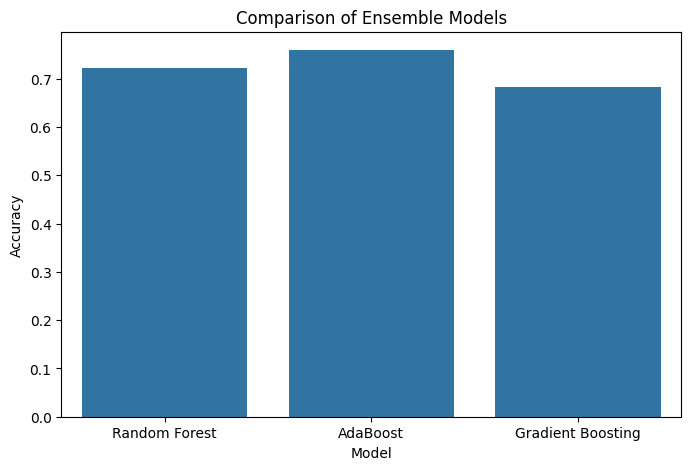

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Comparison of Ensemble Models")

plt.show()

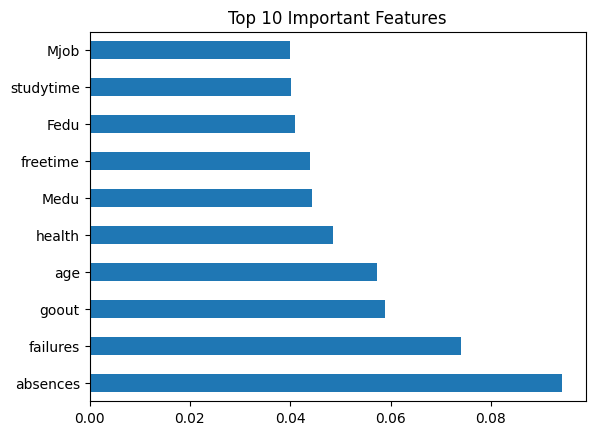

In [20]:
importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")

plt.show()